In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors


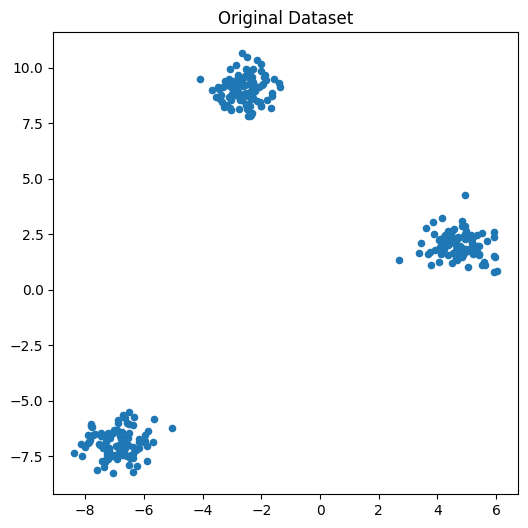

In [2]:
np.random.seed(42)

X, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.6,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=20)
plt.title("Original Dataset")
plt.show()


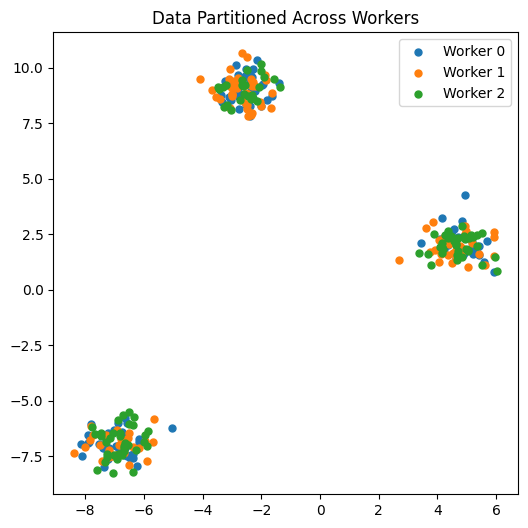

In [3]:
# simulate 3 workers
partitions = np.array_split(X, 3)

plt.figure(figsize=(6,6))

colors = ["red", "green", "blue"]

for i, part in enumerate(partitions):
    plt.scatter(part[:,0], part[:,1], s=25, label=f"Worker {i}")

plt.title("Data Partitioned Across Workers")
plt.legend()
plt.show()


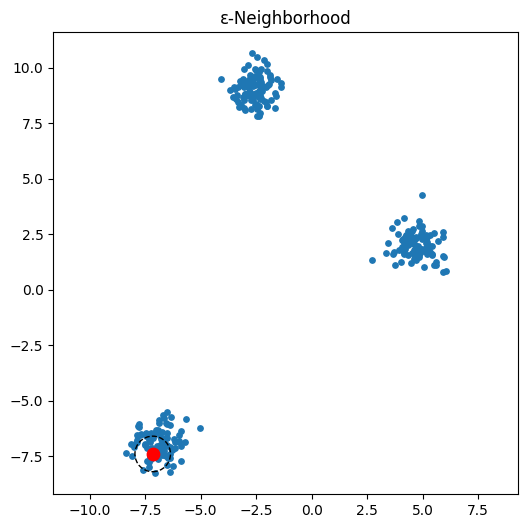

In [4]:
eps = 0.8
point = X[0]

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=15)
plt.scatter(point[0], point[1], c="red", s=80)

circle = plt.Circle(point, eps, fill=False, linestyle="--")
plt.gca().add_patch(circle)

plt.title("ε-Neighborhood")
plt.axis("equal")
plt.show()


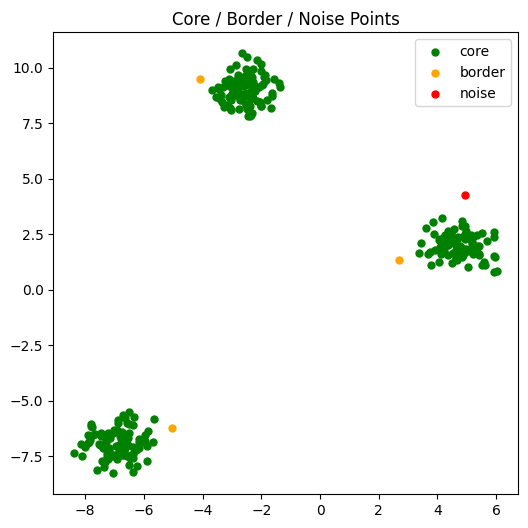

In [5]:
min_pts = 5

nbrs = NearestNeighbors(radius=eps).fit(X)
neighbors = nbrs.radius_neighbors(X, return_distance=False)

labels = []
for neigh in neighbors:
    if len(neigh) >= min_pts:
        labels.append("core")
    elif len(neigh) > 1:
        labels.append("border")
    else:
        labels.append("noise")

color_map = {"core":"green", "border":"orange", "noise":"red"}

plt.figure(figsize=(6,6))
for lbl in ["core","border","noise"]:
    pts = X[np.array(labels) == lbl]
    plt.scatter(pts[:,0], pts[:,1], c=color_map[lbl], label=lbl, s=25)

plt.title("Core / Border / Noise Points")
plt.legend()
plt.show()


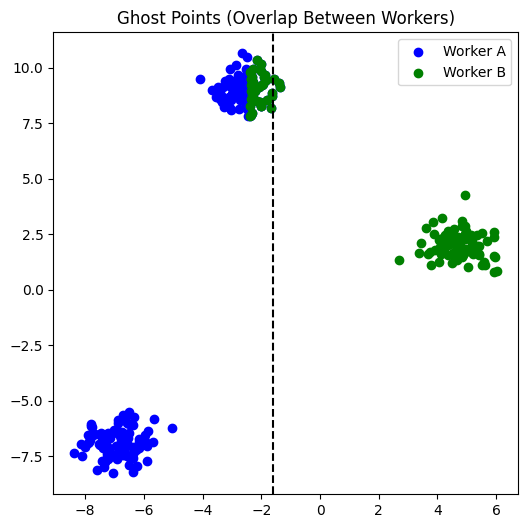

In [6]:
boundary_x = np.mean(X[:,0])

left = X[X[:,0] <= boundary_x + eps]
right = X[X[:,0] > boundary_x - eps]

plt.figure(figsize=(6,6))
plt.scatter(left[:,0], left[:,1], c="blue", label="Worker A")
plt.scatter(right[:,0], right[:,1], c="green", label="Worker B")

plt.axvline(boundary_x, linestyle="--", color="black")
plt.title("Ghost Points (Overlap Between Workers)")
plt.legend()
plt.show()


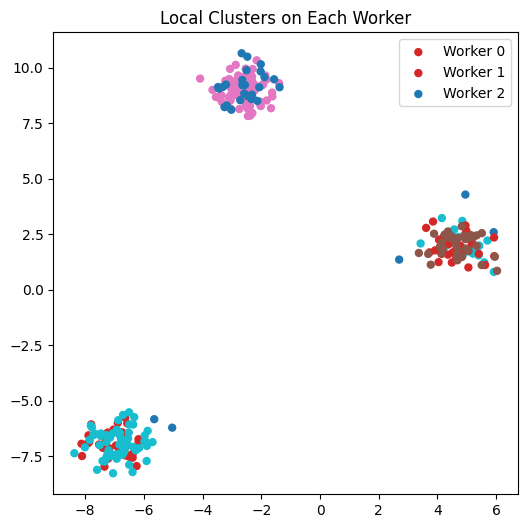

In [7]:
from sklearn.cluster import DBSCAN

plt.figure(figsize=(6,6))

for i, part in enumerate(partitions):
    model = DBSCAN(eps=eps, min_samples=min_pts)
    labels = model.fit_predict(part)
    plt.scatter(
        part[:,0],
        part[:,1],
        c=labels,
        cmap="tab10",
        s=25,
        label=f"Worker {i}"
    )

plt.title("Local Clusters on Each Worker")
plt.legend()
plt.show()


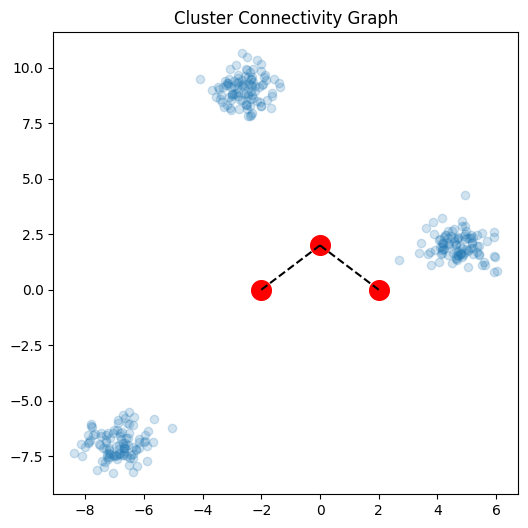

In [8]:
# fake cluster centroids (for visualization)
centers = np.array([
    [-2, 0],
    [0, 2],
    [2, 0]
])

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], alpha=0.2)
plt.scatter(centers[:,0], centers[:,1], s=200, c="red")

for i in range(len(centers)-1):
    plt.plot(
        [centers[i,0], centers[i+1,0]],
        [centers[i,1], centers[i+1,1]],
        'k--'
    )

plt.title("Cluster Connectivity Graph")
plt.show()


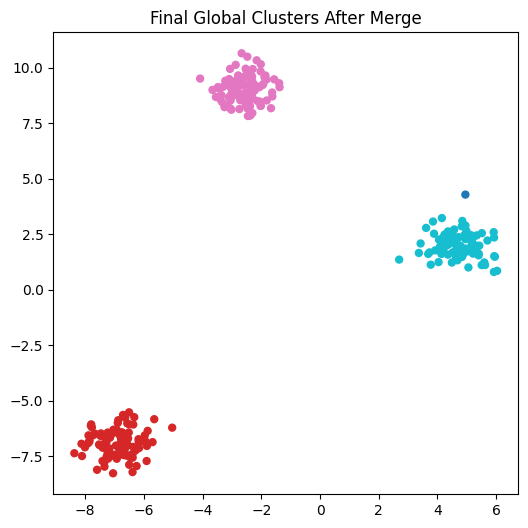

In [9]:
plt.figure(figsize=(6,6))

model = DBSCAN(eps=eps, min_samples=min_pts)
labels = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels, cmap="tab10", s=25)
plt.title("Final Global Clusters After Merge")
plt.show()
